In [1]:
# pyrefly: ignore [missing-import]
%matplotlib inline
import sys
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [2]:
def fetch_and_prepare_data(ticker, start_date, end_date, seq_len=60):
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
    df = df.dropna()
    close_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    
    features = pd.DataFrame(index=df.index)
    features['Close'] = df[close_col]
    features['Return'] = df[close_col].pct_change()
    features['Volatility'] = df['High'] / df['Low'] - 1
    features['Volume_Log'] = np.log1p(df['Volume'])
    features = features.dropna()
    
    data_array = features.values
    X, Y = [], []
    for i in range(len(data_array) - seq_len):
        X.append(data_array[i : i + seq_len])
        Y.append(data_array[i + seq_len, 1])
        
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(Y), dtype=torch.float32)

class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super(RevIN, self).__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))

    def forward(self, x, mode='norm'):
        if mode == 'norm':
            self.mean = torch.mean(x, dim=1, keepdim=True)
            self.std = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps)
            x_norm = (x - self.mean) / self.std
            return x_norm * self.gamma + self.beta
        else:
            x_denorm = (x - self.beta) / self.gamma
            return x_denorm * self.std + self.mean

class DeStationaryAttention(nn.Module):
    def __init__(self, d_model):
        super(DeStationaryAttention, self).__init__()
        self.d_model = d_model
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.tau_proj = nn.Linear(d_model, 1)
        self.delta_proj = nn.Linear(d_model, 1)

    def forward(self, x, u_regime):
        Q, K, V = self.q_proj(x), self.k_proj(x), self.v_proj(x)
        tau = self.tau_proj(u_regime) 
        delta = self.delta_proj(u_regime) 
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_model ** 0.5)
        attn = torch.nn.functional.softmax(scores + tau, dim=-1) + delta
        return torch.matmul(attn, V)

class ProposedModel(nn.Module):
    def __init__(self, num_vars=4, d_model=32):
        super().__init__()
        self.revin = RevIN(num_vars)
        self.embedding = nn.Linear(num_vars, d_model)
        self.regime_encoder = nn.Linear(num_vars, d_model) 
        self.attention = DeStationaryAttention(d_model)
        self.predictor = nn.Linear(d_model, num_vars)
        
    def forward(self, x):
        x_norm = self.revin(x, mode='norm')
        u_regime = self.regime_encoder(torch.mean(x_norm, dim=1, keepdim=True))
        emb = self.embedding(x_norm)
        out = self.attention(emb, u_regime)
        pred_norm = self.predictor(out[:, -1, :])
        pred = self.revin(pred_norm.unsqueeze(1), mode='denorm').squeeze(1) 
        return pred[:, 1]

class DLinear(nn.Module):
    def __init__(self, seq_len=60):
        super().__init__()
        self.linear_trend = nn.Linear(seq_len, 1)
        self.linear_seasonal = nn.Linear(seq_len, 1)
        self.avg = nn.AvgPool1d(kernel_size=25, stride=1, padding=12)

    def forward(self, x):
        x_ret = x[:, :, 1] 
        trend = self.avg(x_ret.unsqueeze(1)).squeeze(1)
        return self.linear_trend(trend) + self.linear_seasonal(x_ret - trend)

class PatchTST_Simplified(nn.Module):
    def __init__(self, seq_len=60, patch_len=12, d_model=32):
        super().__init__()
        self.patch_len = patch_len
        self.num_patches = seq_len // patch_len
        self.proj = nn.Linear(patch_len, d_model)
        self.transformer = nn.TransformerEncoderLayer(d_model, nhead=4, batch_first=True)
        self.predict = nn.Linear(self.num_patches * d_model, 1)
        
    def forward(self, x):
        B = x.size(0)
        patches = x[:, :, 1].view(B, self.num_patches, self.patch_len)
        out = self.transformer(self.proj(patches))
        return self.predict(out.view(B, -1)).squeeze(-1)

class iTransformer_Simplified(nn.Module):
    def __init__(self, seq_len=60, d_model=32):
        super().__init__()
        self.proj = nn.Linear(seq_len, d_model)
        self.transformer = nn.TransformerEncoderLayer(d_model, nhead=4, batch_first=True)
        self.predict = nn.Linear(d_model, 1)
        
    def forward(self, x):
        x = x.permute(0, 2, 1) 
        out = self.transformer(self.proj(x))
        return self.predict(out)[:, 1, 0]


In [3]:
class FinancialLoss(nn.Module):
    def __init__(self, lambda_pred=1.0, lambda_sr=0.1, lambda_turn=0.01, lambda_down=0.01, c=0.001, s=0.0005):
        super().__init__()
        self.lambdas = (lambda_pred, lambda_sr, lambda_turn, lambda_down)
        self.c, self.s = c, s
        self.huber = nn.HuberLoss()

    def forward(self, r_pred, r_true, w_prev):
        w_t = torch.tanh(r_pred / 0.05)
        loss_pred = self.huber(r_pred, r_true)
        
        turnover_l1 = torch.abs(w_t - w_prev)
        turnover_l2 = (w_t - w_prev)**2
        r_net = (w_t * r_true) - (self.c * turnover_l1) - (self.s * turnover_l2)
        
        mean_r_net = torch.mean(r_net)
        std_r_net = torch.sqrt(torch.var(r_net) + 1e-5)
        sharpe_penalty = mean_r_net / std_r_net
        
        loss_turnover = torch.mean(turnover_l1)
        downside = torch.mean(torch.clamp(r_net, max=0) ** 2)
        
        loss = (self.lambdas[0] * loss_pred) - (self.lambdas[1] * sharpe_penalty) + \
               (self.lambdas[2] * loss_turnover) + (self.lambdas[3] * downside)
        return loss, w_t

def train_and_generate_signals(models, X_train, Y_train, X_test, epochs=5):
    train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=False)
    signals_dict = {}
    financial_criterion = FinancialLoss()
    mse_criterion = nn.MSELoss()
    
    for name, model in models.items():
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        model.train()
        for epoch in range(epochs):
            w_prev_full = torch.zeros(32) 
            for bx, by in train_loader:
                curr_batch_size = bx.size(0)
                w_prev = w_prev_full[:curr_batch_size]
                optimizer.zero_grad()
                preds = model(bx)
                if name == "ProposedModel":
                    loss, w_t = financial_criterion(preds, by, w_prev)
                    w_prev_full[:curr_batch_size] = w_t.detach()
                else:
                    loss = mse_criterion(preds, by)
                loss.backward()
                optimizer.step()
                
        model.eval()
        with torch.no_grad():
            preds = model(X_test)
            signals_dict[name] = torch.tanh(preds / 0.05).numpy()
            
    return signals_dict

def calculate_financial_metrics(returns_true, signals, c=0.001, s=0.0005):
    r_net_list, cum_returns = [], [1.0]
    w_prev = 0.0
    total_fee, total_slippage, total_gross_return = 0.0, 0.0, 0.0 
    
    for w_t, r_t in zip(signals, returns_true):
        turnover_l1 = abs(w_t - w_prev)
        turnover_l2 = (w_t - w_prev)**2
        fee = c * turnover_l1
        slippage = s * turnover_l2
        total_fee += fee
        total_slippage += slippage
        
        gross_return = w_t * r_t
        total_gross_return += gross_return
        r_net = gross_return - fee - slippage
        
        r_net_list.append(r_net)
        cum_returns.append(cum_returns[-1] * (1 + r_net))
        w_prev = w_t
        
    r_net_array = np.array(r_net_list)
    ann_return = np.mean(r_net_array) * 252
    volatility = np.std(r_net_array) * np.sqrt(252)
    sharpe_ratio = ann_return / (volatility + 1e-8)
    
    cum_array = np.array(cum_returns[1:])
    max_dd = np.max((np.maximum.accumulate(cum_array) - cum_array) / np.maximum.accumulate(cum_array))
    
    return {
        "Net Profit (%)": (cum_returns[-1] - 1.0) * 100,
        "Gross Profit (%)": total_gross_return * 100,
        "Total Fees (%)": total_fee * 100,
        "Slippage (%)": total_slippage * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_dd * 100,
        "Cum_Returns": cum_array
    }

def run_pipeline_for_asset(ticker):
    X, Y = fetch_and_prepare_data(ticker, "2019-01-01", "2024-01-01")
    split_idx = int(len(X) * 0.75) 
    X_train, Y_train = X[:split_idx], Y[:split_idx]
    X_test, Y_test = X[split_idx:], Y[split_idx:]
    
    models = {
        "DLinear": DLinear(),
        "PatchTST": PatchTST_Simplified(),
        "iTransformer": iTransformer_Simplified(),
        "ProposedModel": ProposedModel() 
    }
    
    signals_dict = train_and_generate_signals(models, X_train, Y_train, X_test)
    
    results, plot_data = {}, {}
    for name, signals in signals_dict.items():
        metrics = calculate_financial_metrics(Y_test.numpy(), signals)
        plot_data[name] = metrics.pop("Cum_Returns")
        results[name] = metrics
        
    metrics_df = pd.DataFrame(results).T
    print("-" * 105)
    print(f"RESULTS FOR {ticker}:")
    print(metrics_df.round(3).to_string())
    print("-" * 105)
    
    plt.figure(figsize=(12, 6))
    for model_name, cum_ret in plot_data.items():
        plt.plot(cum_ret, label=model_name, linewidth=1.5)
    plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Baseline (1.0)')
    plt.title(f"Financial Backtesting: Portfolio Value - {ticker}")
    plt.xlabel("Trading Days (Out-of-Sample)")
    plt.ylabel("Cumulative Returns")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


---------------------------------------------------------------------------------------------------------
RESULTS FOR SPY:
              Net Profit (%) Gross Profit (%) Total Fees (%)  Slippage (%) Sharpe Ratio Max Drawdown (%)
DLinear         [-1.8011868]      [1.0588323]    [2.6476815]  [0.21623129]    -1.044573          2.44816
PatchTST            4.148161         6.680984        2.35246       0.17493     0.901436         3.013249
iTransformer       -3.400439        -3.264724       0.175472      0.001585    -1.677531         3.519918
ProposedModel            NaN              NaN            NaN           NaN          NaN              NaN
---------------------------------------------------------------------------------------------------------


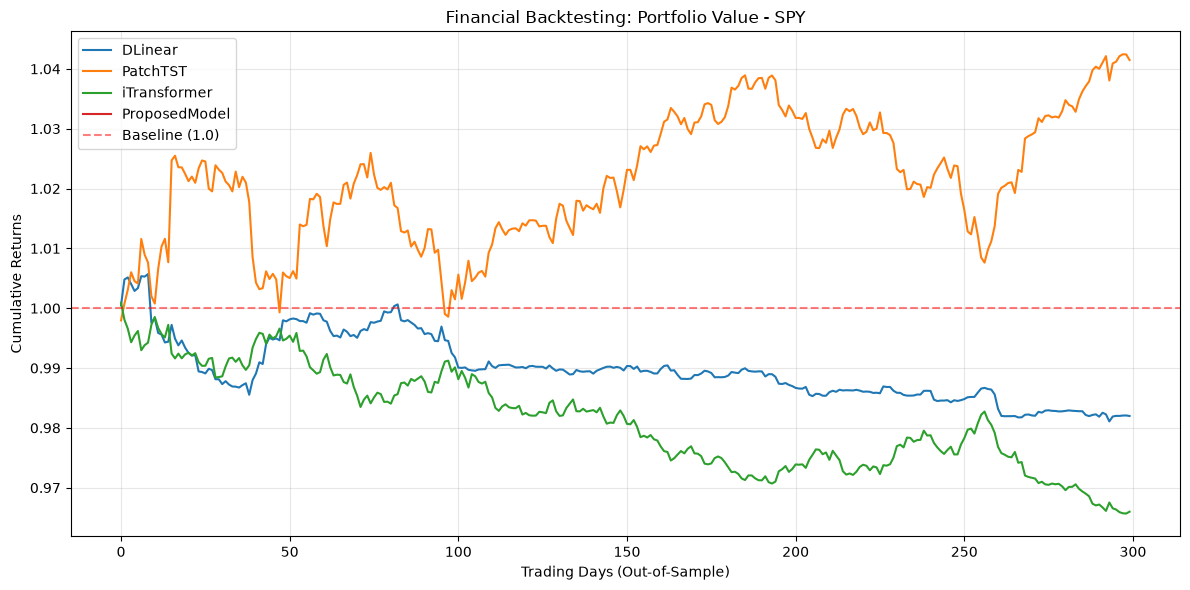

In [4]:
run_pipeline_for_asset('SPY')

---------------------------------------------------------------------------------------------------------
RESULTS FOR BTC-USD:
              Net Profit (%) Gross Profit (%) Total Fees (%)  Slippage (%) Sharpe Ratio Max Drawdown (%)
DLinear         [-2.4763167]     [0.16391276]    [2.4818885]  [0.11562065]    -0.478614         6.555306
PatchTST            15.66453        23.299997       7.108986      0.926787     0.965333         6.562368
iTransformer       12.499487        12.201199       0.178052        0.0011      1.30262          3.44715
ProposedModel      26.395166        28.605812       2.240851      0.128691     0.840893         15.58991
---------------------------------------------------------------------------------------------------------


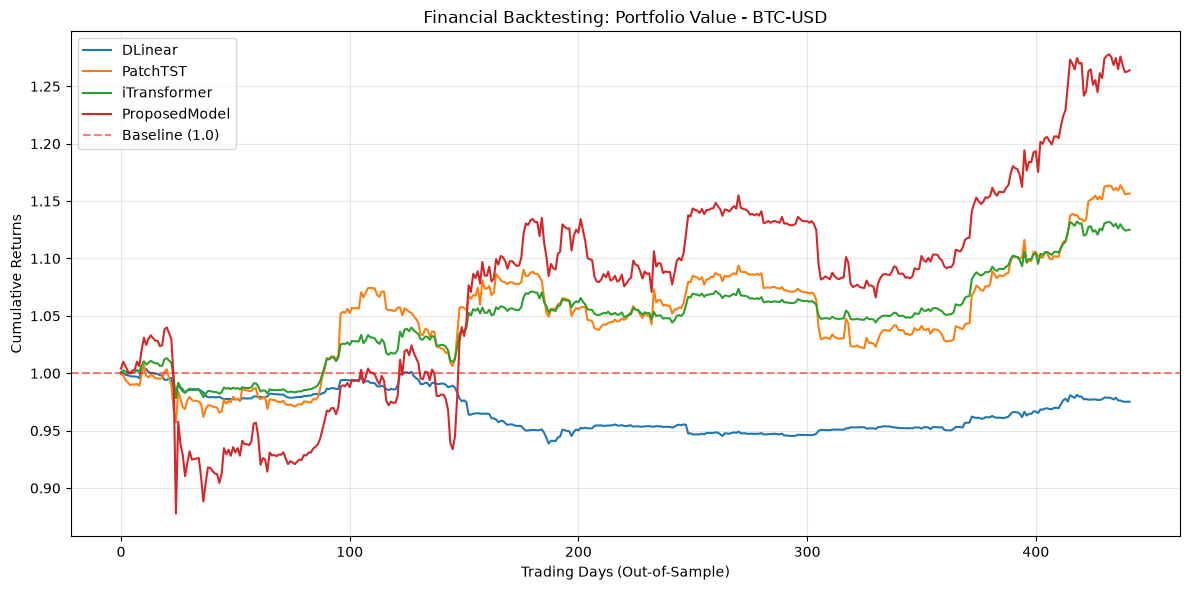

In [5]:
run_pipeline_for_asset('BTC-USD')